# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

**Métriques de référence (test split 20% de 12k)** : F1 macro = 0.5018, ROC-AUC = 0.7296.

**Features** : 14 colonnes  — `loan_amnt`, `term`, `int_rate`, `installment`, `grade`, `emp_length`, `home_ownership`, `annual_inc`, `verification_status`, `purpose`, `dti`, `delinq_2yrs`, `fico_range_low`, `revol_util`.

**Architecture** : RandomForest (`n_estimators=100`, `max_depth=None`).

## 2. EDA du nouveau dataset

In [3]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
print(df.shape)
print(df.head(5))
print(df.dtypes)
print(df.describe(include="all"))
# term et emp_length sont en object alors que ce sont des nombres

print(df.isna().mean().sort_values(ascending=False).head(10))
# taux de NaN : emp_length 3,97 % / revol_util 1,62 % / le reste 0

print(df.info())
print(df["loan_status"].value_counts())

(24000, 15)
   loan_amnt       term  int_rate  installment grade emp_length  \
0       5700  36 months      6.71       175.24     A    3 years   
1       8700  36 months     11.83       288.26     C    3 years   
2       7900  36 months     11.25       259.57     C    5 years   
3      35800  36 months      9.61      1148.62     B    3 years   
4      16000  60 months     14.43       375.87     C    8 years   

  home_ownership  annual_inc verification_status             purpose    dti  \
0       MORTGAGE       38900        Not Verified      small_business  17.92   
1           RENT       51400            Verified    home_improvement  21.26   
2           RENT       38900            Verified  debt_consolidation  13.56   
3       MORTGAGE       82900            Verified         credit_card  29.99   
4       MORTGAGE       32700        Not Verified    home_improvement  17.98   

   delinq_2yrs  fico_range_low  revol_util loan_status  
0            0             738        78.1  Fully Pai

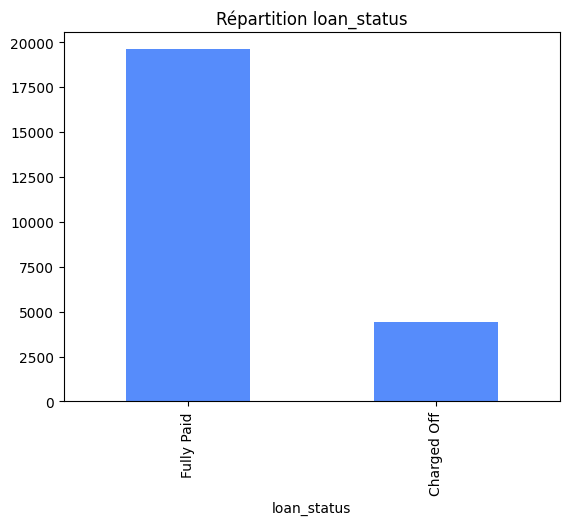

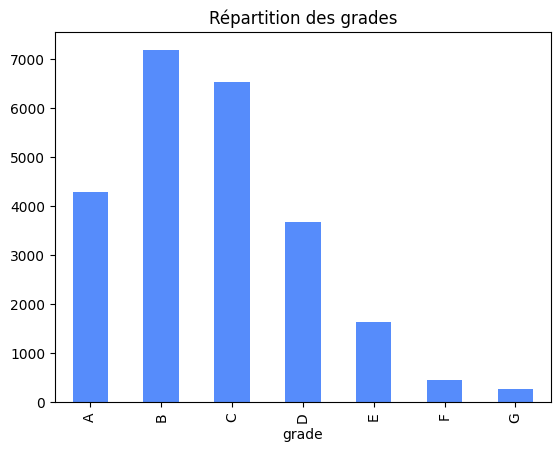

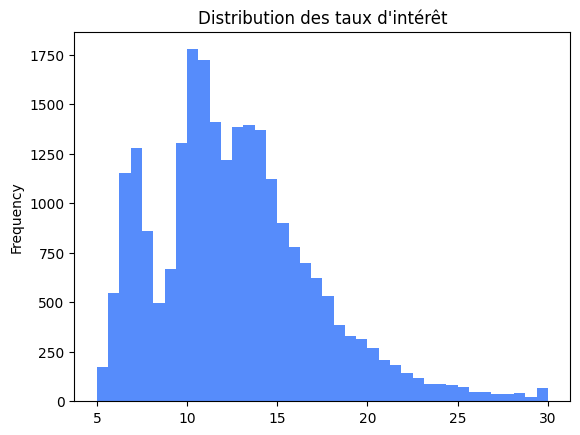

In [4]:
df["loan_status"].value_counts().plot(kind="bar", title="Répartition loan_status")
plt.show()

df["grade"].value_counts().sort_index().plot(kind="bar", title="Répartition des grades")
plt.show()

df["int_rate"].plot(kind="hist", bins=40, title="Distribution des taux d'intérêt")
plt.show()

### Ce qui change par rapport à 2017

- Le dataset est deux fois plus gros qu'en 2017 (24 000 lignes contre 12 000).
- Il y a plus de mauvais payeurs : environ 18 % de défauts, contre 15 % avant.
- Il y a maintenant des trous dans les données : 4 % sur emp_length et 1,6 % sur revol_util, alors qu'en 2017 tout était rempli.
- Les emprunteurs sont plus risqués : un quart d'entre eux ont un grade D à G, c'est plus qu'avant.
- Les taux d'intérêt suivent : ils sont tirés vers le haut à cause de ces profils plus risqués.

## 3. Préparation et split

Split stratifié, `random_state=42`.

In [5]:
y = df["loan_status"].map({"Fully Paid": 0, "Charged Off": 1})
X = df.drop(columns=["loan_status"])

## 4 : stratify

In [6]:
# Split SANS stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test balance: ", y_test.value_counts(normalize=True).round(3).to_dict())
# 18,5 % de défauts dans le train contre 18 % dans le test : proches mais pas identiques, car le découpage est aléatoire et ne force pas l'équilibre

Train balance: {0: 0.815, 1: 0.185}
Test balance:  {0: 0.82, 1: 0.18}


In [7]:
# Split AVEC stratify=y : force la même proportion de défauts dans train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test balance: ", y_test.value_counts(normalize=True).round(3).to_dict())
# Train balance: {0: 0.816, 1: 0.184}
# Test balance:  {0: 0.816, 1: 0.184}
# train et test ont la même proportion de défauts (18,4 %) grâce à stratify


Train balance: {0: 0.816, 1: 0.184}
Test balance:  {0: 0.816, 1: 0.184}


In [8]:
# 5 : random_state
X_train_1, X_test_1, _, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_2, X_test_2, _, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Index 1re ligne split 1 :", X_train_1.iloc[0].name)
print("Index 1re ligne split 2 :", X_train_2.iloc[0].name)
print("Mêmes shapes :", X_train_1.shape == X_train_2.shape)
print("Même 1re ligne :", X_train_1.iloc[0].equals(X_train_2.iloc[0]))
# même index d'origine + deux True -> le split est reproductible grâce à random_state=42

Index 1re ligne split 1 : 9462
Index 1re ligne split 2 : 9462
Mêmes shapes : True
Même 1re ligne : True


## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

### Récap des runs

| Config | F1 défaut | Recall défaut | Precision défaut | ROC-AUC | Verdict (court) |
|---|---|---|---|---|---|
| exp_001 default | 0.1289 | 0.0725 | **0.58** | 0.7134 | rate 93% des défauts (seuil inadapté) |
| exp_002 balanced | 0.4362 | 0.6410 | 0.33 | **0.7444** | attrape 64%, precision chute — utile métier |
| exp_003 weighted {0:1,1:8} | 0.4045 | **0.8573** | 0.2647 | 0.7409 | recall 86% mais trop agressif (F1 macro s'effondre) |
| exp_004 balanced profond | 0.4170 | 0.5051 | 0.3551 | 0.7400 | recall retombe à 51% — pas intéressant |
| exp_005 balanced court | **0.4377** | 0.6908 | 0.3204 | 0.7428 | recall 69%, F1 stable, le + rapide |
| exp_006 profond + leaf=50 | 0.4325 | 0.6693 | 0.3195 | 0.7442 | ≈ exp_005 mais 4× plus lent |

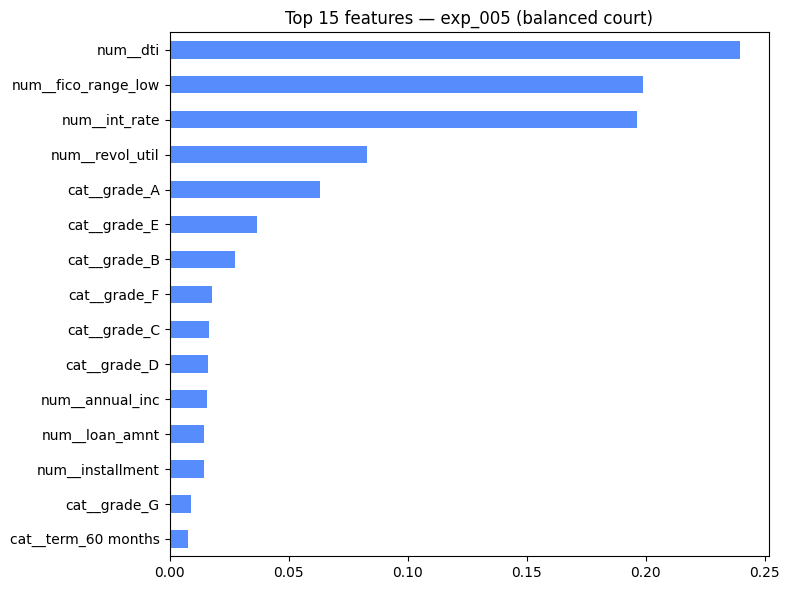

In [9]:
import joblib
# 4 : feature_importances_
pipe = joblib.load('../models/pyrenex_risk_v2_balanced_shallow.joblib')
names = pipe.named_steps['preprocess'].get_feature_names_out()
importances = pipe.named_steps['classifier'].feature_importances_

top = pd.Series(importances, index=names).sort_values(ascending=False).head(15)

top.sort_values().plot(kind='barh', figsize=(8, 6), title='Top 15 features — exp_005 (balanced court)')
plt.tight_layout()
plt.show()

# les features les plus importantes (et de loin), donc celles qui ont été décisives pour déparer défauts/remboursé :
# - taux d'endettement (dettes / revenu) (dti)
# - la note de crédit de l'emprunteur (fico_range_low)
# - taux d'intérêt du prêt (int_rate)
# à noter qu'il s'agit de corrélations et pas variables causales

In [17]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion (seuil 0.5) — exp_005")
print("                 Prédiction Remboursé  Prédiction Défaut")
print(f"Vrai Remboursé   {cm[0,0]:>16}   {cm[0,1]:>16}")
print(f"Vrai Défaut      {cm[1,0]:>16}   {cm[1,1]:>16}")
print()
print(f"Recall défaut    : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Precision défaut : {precision_score(y_test, y_pred, pos_label=1):.4f}")

Matrice de confusion (seuil 0.5) — exp_005
                 Prédiction Remboursé  Prédiction Défaut
Vrai Remboursé               2623               1294
Vrai Défaut                   273                610

Recall défaut    : 0.6908
Precision défaut : 0.3204


In [13]:
from sklearn.metrics import f1_score

print(f"F1 macro       : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 défaut (bin): {f1_score(y_test, y_pred, pos_label=1):.4f}")

# le plus bas est le F1 défaut (.43 vs .60)
# parce que le F1 macro inclut les métriques de la classe majoritaire (remboursé) qui est plus simple à prédire
# le F1 macro est la moyenne des F1 des deux classes défaut et remboursé

F1 macro       : 0.6039
F1 défaut (bin): 0.4377


In [14]:
from sklearn.metrics import roc_auc_score

y_proba = pipe.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC      : {roc_auc:.4f}")
print(f"vs aléatoire : +{roc_auc - 0.5:.4f} au-dessus de 0.5")

# avec un ROC-AUC de .74 notre modèle est meilleur qu'un classement aléatoire

ROC-AUC      : 0.7428
vs aléatoire : +0.2428 au-dessus de 0.5


In [ ]:
from sklearn.metrics import precision_score, recall_score

y_pred_03 = (y_proba > 0.3).astype(int)
cm_03 = confusion_matrix(y_test, y_pred_03)

print("Matrice de confusion (seuil 0.3) — exp_005")
print("                 Prédiction Remboursé  Prédiction Défaut")
print(f"Vrai Remboursé   {cm_03[0,0]:>16}   {cm_03[0,1]:>16}")
print(f"Vrai Défaut      {cm_03[1,0]:>16}   {cm_03[1,1]:>16}")
print()
print(f"Recall défaut    : {recall_score(y_test, y_pred_03, pos_label=1):.4f}")
print(f"Precision défaut : {precision_score(y_test, y_pred_03, pos_label=1):.4f}")

# recall incroyable (98%) car on ne rate que 22 défauts; mais la précision déjà basse chute de 32% à 21% (bcp de fausses alertes)
# donc intéressant de jouer sur le seuil si veut être sûr d'avoir un pool avec quasi tous les défauts
# le client doit accepter 79% de fausses alertes (vs 68% à 0.5) pour rattraper 29 points de défauts en plus (recall 69% -> 98%)

y_pred_04 = (y_proba > 0.4).astype(int)
cm_04 = confusion_matrix(y_test, y_pred_04)

print("\nMatrice de confusion (seuil 0.4) — exp_005")
print("                 Prédiction Remboursé  Prédiction Défaut")
print(f"Vrai Remboursé   {cm_04[0,0]:>16}   {cm_04[0,1]:>16}")
print(f"Vrai Défaut      {cm_04[1,0]:>16}   {cm_04[1,1]:>16}")
print()
print(f"Recall défaut    : {recall_score(y_test, y_pred_04, pos_label=1):.4f}")
print(f"Precision défaut : {precision_score(y_test, y_pred_04, pos_label=1):.4f}")

# avec 0.4 de seuil on augmente fortement le recall (de 69% à 89%) et on ne perd que 6 points de précision ; donc ça semble être un bon compromis entre .3 et .5
# le client doit accepter 74% de fausses alertes (vs 68% à 0.5) pour rattraper 20 points de défauts en plus (recall 69% -> 89%)

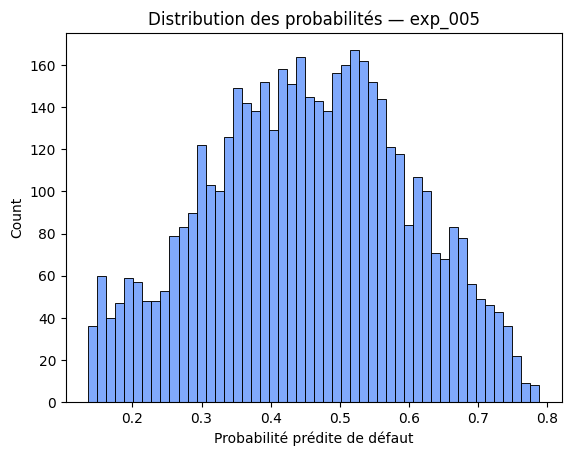

In [19]:
sns.histplot(y_proba, bins=50)
plt.xlabel("Probabilité prédite de défaut")
plt.title("Distribution des probabilités — exp_005")
plt.show()

# quasi une distribution normale, beaucoup de probas au milieu pour lesquelqs le modèle dit une chance sur deux, pas de seuil clair

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [10]:
from sklearn.metrics import f1_score

# TODO : adapte aux noms de tes variables (X, y, et le modèle de la section 4)
scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = ...  # ré-instancie le même modèle qu'en section 4
    model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

AttributeError: 'ellipsis' object has no attribute 'fit'

**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.